# Итоговый проект Спринт 7: Изучение рынка заведений общественного питания Москвы

## Цель и задачи  

**Цель:** Провести исследовательский анализ данных рынка заведений общественного питания Москвы с целью определения бизнес-стратегии заказчика

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
 TBD
4. Сформулировать выводы по проведённому анализу.

## Данные

Датасет с заведениями общественного питания Москвы, составленный на основе данных сервисов Яндекс Карты и Яндекс Бизнес на лето 2022 года. Информация, размещённая в сервисе Яндекс Бизнес, могла быть добавлена пользователями или найдена в общедоступных источниках.

Данные состоят из двух датасетов:

1. rest_info.csv - содержит информацию о заведениях общественного питания
2. rest_price.csv - содержит информацию о среднем чеке в заведениях общественного питания

### Описание датасета 'rest_info.csv'

- 'name' — название заведения;
- 'address' — адрес заведения;
- 'district' — административный район, в котором находится заведение;
- 'category' — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- 'hours' — информация о днях и часах работы;
- 'rating' — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- 'chain' — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым;
- 'seats' — количество посадочных мест


### Описание датасета 'rest_price.csv'

- 'price' — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- 'avg_bill' — строка, которая хранит среднюю стоимость заказа в виде диапазона;
- 'middle_avg_bill' — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»;
- 'middle_coffee_cup' -  число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»;


## Структура проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговые выводы.

## 1. Загрузка данных и знакомство с ними

Начнём с загрузки библиотек и датасетов `rest_info.csv` и `rest_price.csv`. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn, а также phik для построения матрицы корреляции. Данные датасетов сохраним в двух переменных: `info_df` и `price_df`.

In [1]:
!pip install phik -U

In [2]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

In [3]:
# Выгружаем данные в переменные info_df и price_df

info_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
price_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

Познакомимся с данными датасета `rest_info.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [4]:
info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [5]:
info_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


Датасет rest_info.csv содержит 9 столбцов и 8406 строк, в которых представлена сводная информация о заведении: его название, категорию, адрес, время работы, количество мест, рейтинг

После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов приведены к одному виду: нижний регистр, каждое название - одно слово, действий с названиями не потребуется.
- Все представленные данные содержат строковые значения в формате object, числовые значения, хранятся в типах данных int64 или float64.
- Значения в столбце chain представлены целыми числами и содержат 1 или 0 — размерность этих данных можно оптимизировать.
- Значения в столбце rating содержат дробные значения до 5.0  - размерность этих данных можно оптимизировать.
- В столбце seats данные содержатся в типе float - их стоит привести к целочисленному типу.
- Пропуски содержатся в столбцах hours и seats. Однако следует проверить и другие столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных.

Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

Познакомимся с данными датасета `rest_price.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [6]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


In [7]:
price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


Датасет rest_price.csv содержит 4058 строк и 5 столбцов, в которых представлена ценовая категория, средний счет, средняя стоимость чашки кофе

После первичного анализа можно сделать следующие выводы:

- Названия столбцов приведены к нижнему регистру, snake_case и действий по ним не требуется.
- Столбцы id, price, avg_bill представлены типом object со строковой информацией.
- Столбцы middle_avg_bill и middle_coffee_cup - float64 - можно привести к меньшей размерности для экономии памяти, так как средний чек и стоимость кофе не могут быть аномально высокими.
- Во всех столбцах, кроме id часть данных пропущена, что может сузить набор данных для анализа. Пропуски потребуют предобработки. Удалить строки с пропускам не получится, так как они занимают весомую часть данных

In [8]:
# Для дальнейшей обработки объединим два датафрейма: добавим в датафрейм заведений информацию о ценах, соединив их по полю id таким образом, чтобы дополнить данные для тех заведений, для которых такая информация есть.
# Так как размерность датафреймов отличается практически в два раза, можно сделать вывод, что примерно для половины заведений нет информации о ценах

full_df = pd.merge(info_df, price_df, on='id', how='left')

## 2. Предобработка данных

### 2.1 Преобразование типов и размерности данных 

In [9]:
# Подберем размерность типов данных в датасетах, преобразуем типы:

#info_df
info_df['chain'] = pd.to_numeric(info_df['chain'], downcast='integer')
info_df['rating'] = pd.to_numeric(info_df['rating'], downcast='float')

#price_df
price_df['middle_avg_bill'] = pd.to_numeric(price_df['middle_avg_bill'], downcast='float')
price_df['middle_coffee_cup'] = pd.to_numeric(price_df['middle_coffee_cup'], downcast='float')

Для преобразования значений info_df['seats'] в целочисленный тип необходимо заполнить пропущенные значения в столбце на индикативное значение, например -1. Таким образом, мы получим 0 для заведений, где число мест нет (например, заведения работают только навынос) и -1 - для заведений, где число мест не указано. Далее приведем значения к целочисленному типу

In [10]:
info_df['seats'] = info_df['seats'].fillna(-1)
info_df['seats'] = info_df['seats'].astype('int32')

In [11]:
# Проверим изменения, запросив информацию о датасетах

info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float32
 7   chain     8406 non-null   int8   
 8   seats     8406 non-null   int32  
dtypes: float32(1), int32(1), int8(1), object(6)
memory usage: 468.0+ KB


In [12]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float32
 4   middle_coffee_cup  535 non-null    float32
dtypes: float32(2), object(3)
memory usage: 126.9+ KB


## 2.2 Работа с пропущенными значениям в датафреймах

In [13]:
# Выведем информацию о получившемся датафрейме и первые 5 его строк

full_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 853.9+ KB


In [14]:
full_df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


Можно сделать вывод, что потерь данных не произошло, слияние по идентификатору было успешным. Далее можно работать с общим датафреймом

In [15]:
# Определим количество пустых данных в объединенном датафрейме (в %)

empty_data = round(full_df.isna().sum() / full_df.shape[0],2) * 100
print(empty_data.sort_values(ascending=False))

middle_coffee_cup    94.0
middle_avg_bill      63.0
price                61.0
avg_bill             55.0
seats                43.0
hours                 6.0
id                    0.0
name                  0.0
category              0.0
address               0.0
district              0.0
rating                0.0
chain                 0.0
dtype: float64


Можно сделать вывод, что пропущенные значения в столбце hours можно игнорировать. 
Данные, пропущенные в avg_bill, price, middle_avg_bill  и middle_coffee_cup не заполнены более чем по половине заведений, что может повлиять на анализ ценового уровня заведений, но при этом не повлияет на расчеты по рейтингу, времени работы - потому не требует удаления, однако, возможно в дальнейшем анализе потребует нормализации/дедубликации.

## 2.3 Проведем анализ на явные и неявные дубликаты, и обработку таких случаев

In [16]:
# Для начала подсчитаем количество уникальных значений в столбцах name и address

unique_names_count = full_df['name'].nunique()
unique_address_count = full_df['address'].nunique()

print('Количество уникальных заведений по названию: ', unique_names_count)
print('Количество уникальных адресов в датафрейме: ', unique_address_count)

Количество уникальных заведений по названию:  5614
Количество уникальных адресов в датафрейме:  5753


Однако, удаление дубликатов в данном случае может привести к удалению сетевых заведений с одинаковым названием, или заведений, расположенных по одному адресу. Однако, можно привести названия к однообразному виду. Также для дальнейшего анализа приведем к нижнему регистру значение столбцов hours и district

In [17]:
full_df['name'] = full_df['name'].str.lower() 
full_df['address'] = full_df['address'].str.lower() 
full_df['hours'] = full_df['hours'].str.lower() 
full_df['district'] = full_df['district'].str.lower() 

In [18]:
# Проведем проверку нормализованных данных, выведя первые 10 строк датафрейма:

full_df.head(10)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,wowфли,кафе,"москва, улица дыбенко, 7/1",северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,четыре комнаты,ресторан,"москва, улица дыбенко, 36, корп. 1",северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,хазри,кафе,"москва, клязьминская улица, 15",северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,dormouse coffee shop,кофейня,"москва, улица маршала федоренко, 12",северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,иль марко,пиццерия,"москва, правобережная улица, 1б",северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN
5,8a343546b24e4a499ad96eb7d0797a8a,sergio pizza,пиццерия,"москва, ижорская улица, вл8б",северный административный округ,"ежедневно, 10:00–23:00",4.6,0,NaN,средние,NaN,NaN,NaN
6,96ebceb1a09e4e3191133b9fe0379a64,огни города,"бар,паб","москва, клязьминская улица, 9, стр. 3",северный административный округ,пн 15:00–04:00; вт-вс 15:00–05:00,4.4,0,45.0,средние,Средний счёт:199 ₽,199.0,NaN
7,0243288b78024af090b8e947842c969c,mr. уголёк,быстрое питание,"москва, клязьминская улица, 9, стр. 3",северный административный округ,"пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00...",4.7,0,45.0,средние,Средний счёт:200–300 ₽,250.0,NaN
8,36aeb0ffa69c48fdb0021549520deb10,donna maria,ресторан,"москва, дмитровское шоссе, 107, корп. 4",северный административный округ,"ежедневно, 10:00–22:00",4.8,0,79.0,средние,Средний счёт:от 500 ₽,500.0,NaN
9,487167877eb04288bc90d4fa80646fc2,готика,кафе,"москва, ангарская улица, 39",северный административный округ,"ежедневно, 12:00–00:00",4.3,0,65.0,средние,Средний счёт:1000–1200 ₽,1100.0,NaN


In [19]:
# Проведем проверку на наличие дубликатов в столбцах 'name' и 'address'

full_df.duplicated(subset=['name', 'address']).sum()

4

Количество совпадений по обоим полям - 4. Выведем дубликаты на просмотр

In [20]:
full_df[full_df.duplicated(subset=['name', 'address'], keep=False)]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
189,072032ce16dc47bfbc63b672c75bd371,кафе,кафе,"москва, парк ангарские пруды",северный административный округ,"ежедневно, 09:00–23:00",3.2,0,NaN,NaN,NaN,NaN,NaN
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",северный административный округ,"ежедневно, 10:00–22:00",3.2,0,NaN,NaN,NaN,NaN,NaN
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188.0,NaN,NaN,NaN,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188.0,NaN,NaN,NaN,NaN
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",северо-восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150.0,NaN,NaN,NaN,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",северо-восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150.0,NaN,NaN,NaN,NaN
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,булочная,"москва, ярцевская улица, 19",западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276.0,NaN,NaN,NaN,NaN
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"москва, ярцевская улица, 19",западный административный округ,NaN,4.1,0,276.0,NaN,NaN,NaN,NaN


Так как количество дубликатов небольшое, визуально подтверждается, что записи задублированы - проведем удаление дубликатов, оставив первую запись из нескольких

In [21]:
full_df.drop_duplicates(subset=['name', 'address'], keep='first', inplace=True) 

# Запросим информацию о датафрейме, дабы убедиться, что 4 строки удалены

full_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8402 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8402 non-null   object 
 1   name               8402 non-null   object 
 2   category           8402 non-null   object 
 3   address            8402 non-null   object 
 4   district           8402 non-null   object 
 5   hours              7867 non-null   object 
 6   rating             8402 non-null   float64
 7   chain              8402 non-null   int64  
 8   seats              4792 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.0+ KB


## 2.4 Определим заведения с круглосуточной работой и присвоим им новый признак is_24_7

In [22]:
# Для определения круглосуточных заведений напишем функцию, 
# которая будет проверять в строке наличие в поле hours слова круглосуточно. 
# Далее применим данную функцию к датафрейму

def is_24_7 (row):
    if row['hours'] == 'ежедневно, круглосуточно':
        return True
    else:
        return False

full_df['is_24_7'] = full_df.apply(is_24_7, axis=1)

In [23]:
# Определим количество заведений, которые работают ежедневно и круглосуточно, сложив значения нового столбца:

full_df['is_24_7'].sum()

730

Вывод: проведя предварительную обработку данных, мы получили единый датафрейм со всеми значениями, привели поля к нужным форматам, добавили новый признак Круглосточно, ежедневно. В таком режиме работает 730 заведений (менее 10%).
Удаление данных не проводили во избежание потери данных и искажения результатов, так как сетевые заведения могут иметь одинаковое название, а по некоторым адресам также может располагаться несколько заведений, но заменили пропуски в столбце seats на индикатор 0. Также привели значения названий заведений и адресов к нижнему регистру для более удобного анализа. 

## 3. Исследовательский анализ данных

### 3.1 Категоризация заведений

In [24]:
# Определим категории заведений, которые представлены в датафрейме, 
# выведя уникальные категории из соответствующего поля

full_df['category'].unique()

array(['кафе', 'ресторан', 'кофейня', 'пиццерия', 'бар,паб',
       'быстрое питание', 'булочная', 'столовая'], dtype=object)

In [25]:
# Исследуем число заведений в каждной категории:

round(full_df['category'].value_counts(normalize=True), 2)

category
кафе               0.28
ресторан           0.24
кофейня            0.17
бар,паб            0.09
пиццерия           0.08
быстрое питание    0.07
столовая           0.04
булочная           0.03
Name: proportion, dtype: float64

<Axes: title={'center': 'Распределение заведений по категориям'}, xlabel='Категория', ylabel='Количество заведений'>

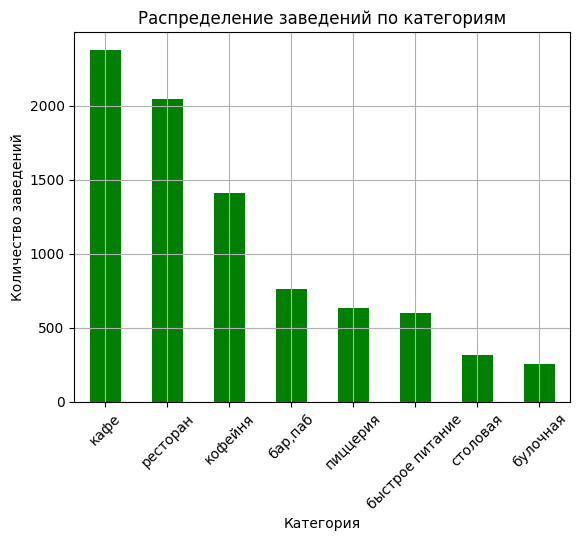

In [26]:
# Можно сделать вывод, что в датафрейме представлено 8 категорий заведений. 
# Выведем визуализацию распределения заведений по категориям. Для этих целей лучше всего подойдет столбчатая диаграмма


full_df['category'].value_counts().plot(kind='bar',
                                        title='Распределение заведений по категориям',
                                        legend=False,
                                        ylabel='Количество заведений',
                                        xlabel='Категория',
                                        rot=45,
                                        grid=True,
                                        color='green') 


График наглядно показывает долю заведений каждой категории в порядке уменьшения. Из наложенной сетки значений видно, что разница между самой объемной категорией и самой маленькой разница более чем в 4 раза. 

### 3.2 Распределение заведений по округам Москвы

In [27]:
# Определим, по каким округам Москвы и в каком количестве присутсвуют различные заведения
# Для начала определим список округов Москвы, которые присутсвуют в датафрейме, а также общее число заведений по данным округам

#places_by_distr_counts['districts'] = full_df['district'].unique()
places_by_distr_counts = full_df.groupby('district', as_index=False)['name'].agg('count')

print(places_by_distr_counts.sort_values('name', ascending=False))

                                  district  name
5       центральный административный округ  2242
2          северный административный округ   898
8             южный административный округ   892
3  северо-восточный административный округ   890
1          западный административный округ   850
0         восточный административный округ   798
6     юго-восточный административный округ   714
7      юго-западный административный округ   709
4   северо-западный административный округ   409


<Axes: title={'center': 'Распределение заведений по административным округам Москвы'}, xlabel='Округ', ylabel='Количество заведений'>

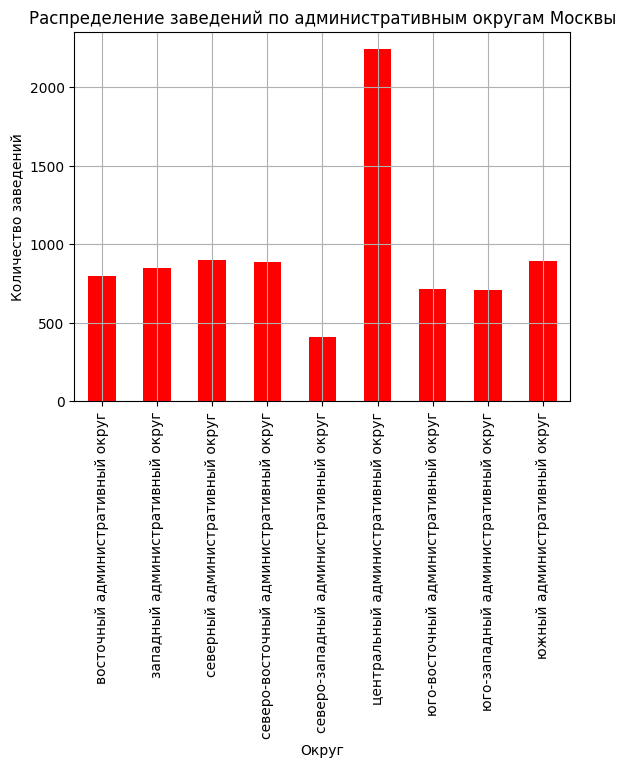

In [28]:
# Выведем визуальное распределение заведений по округам в виде столбчатой диаграммы

places_by_distr_counts.plot(kind='bar',
                            title='Распределение заведений по административным округам Москвы',
                            legend=False,
                            ylabel='Количество заведений',
                            x='district',
                            xlabel='Округ',
                            rot=90,
                            grid=True,
                            color='red') 


Из графика четко видно, что явным лидером по заведениям является Центральный округ, аутсайдером - Северо-Западный. Остальные округа распределены достаточно равномерно

In [29]:
# Теперь определим распределение заведений по категориям по округам Москвы и выведем визуально на график. Для этого сформируем датафрейм, сгруппированный по категориям и округам одновременно

df_cat_distr = full_df.groupby(['category', 'district'])['name'].count().unstack(fill_value=0)

# Выведем первые строки нового датафрейма
df_cat_distr.head()

district,восточный административный округ,западный административный округ,северный административный округ,северо-восточный административный округ,северо-западный административный округ,центральный административный округ,юго-восточный административный округ,юго-западный административный округ,южный административный округ
category,,,,,,,,,
"бар,паб",53,50,68,62,23,364,38,38,68
булочная,25,37,39,28,12,50,13,27,25
быстрое питание,71,62,58,82,30,87,67,61,85
кафе,272,238,234,269,115,464,282,238,264
кофейня,105,150,193,159,62,428,89,96,131


<Axes: title={'center': 'Распределение заведений по категориям по округам Москвы'}, xlabel='Категория', ylabel='Количество заведений'>

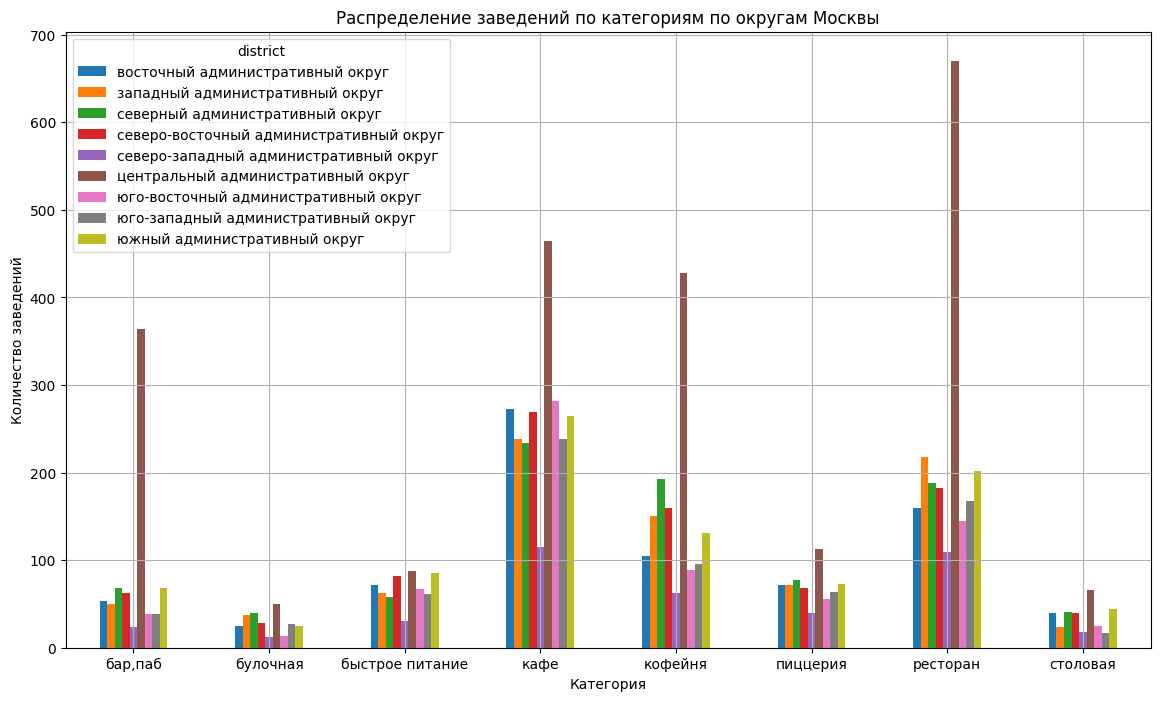

In [30]:
# Визуализируем распределение

df_cat_distr. plot(kind='bar',
                   title='Распределение заведений по категориям по округам Москвы',
                   legend=True,
                   ylabel='Количество заведений',
                   xlabel='Категория',
                   rot=0,
                   grid=True,
                   figsize=(14, 8))

Из данной информации можно сделать вывод, что и общее число заведений, и число заведений каждой из категорий наибольшие в Центральном округе, а наименьшее в Северо-Западном АО. Во всех остальных округах распределение заведений равномерное.

Отдельно выведем распределение по категорям заведений в Центральном округе

<Axes: title={'center': 'Распределение заведений по категориям в Центральном округе'}, xlabel='Категория', ylabel='Количество заведений'>

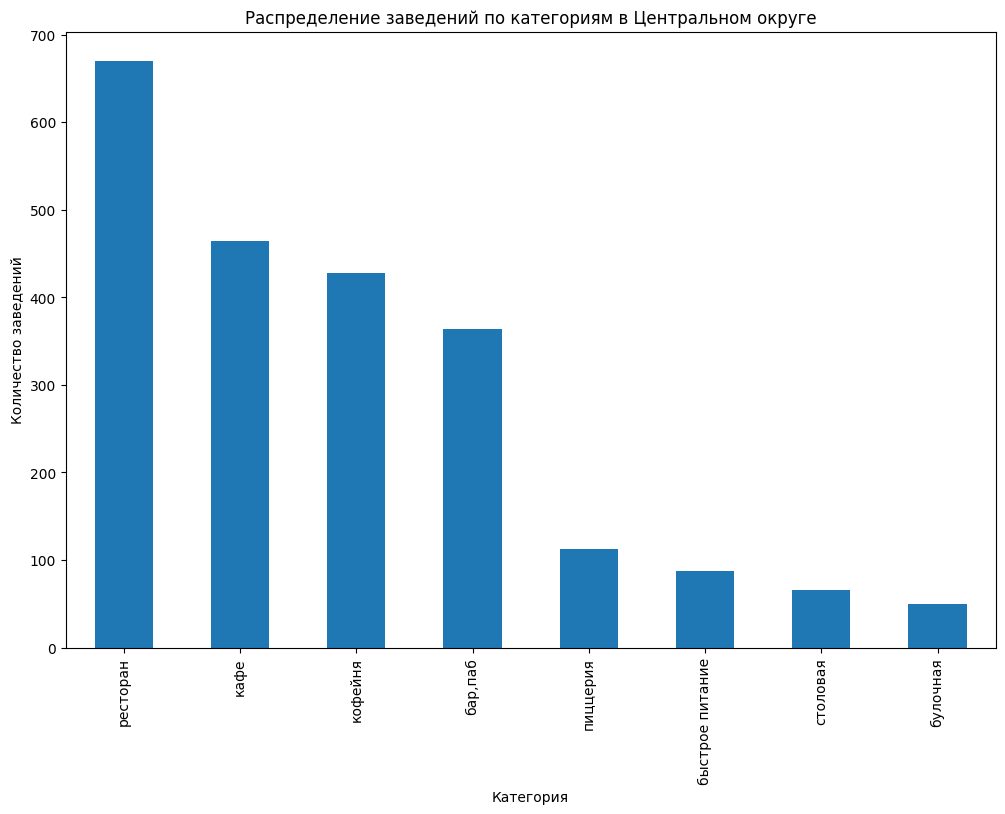

In [32]:
# Подсчитаем заведения по категориям в Центральном округе

cao_categories = full_df.loc[full_df['district'] == 'центральный административный округ'].groupby('category')['id'].count().sort_values(ascending=False)

cao_categories.head()

# Визуализируем на графике

cao_categories.plot(kind='bar',
                    title='Распределение заведений по категориям в Центральном округе',
                    legend=False,
                    xlabel='Категория',
                    ylabel='Количество заведений',
                    figsize=(12, 8))

Для отображения выбрана столбчатая диаграмма, так как количество категорий больше 5, она наглядно показывает, как распределились доли по категориям. Топ-4 категории это Ресторан, Кафе, Кофейня, Бар - остальные категории занимают гораздо более скромные доли в Центральном округе Москвы.

### 3.3 Анализ сетевых и несетевых заведений

<Axes: title={'center': 'Статистика сетевых и несетевых заведений'}, ylabel='Количество заведений'>

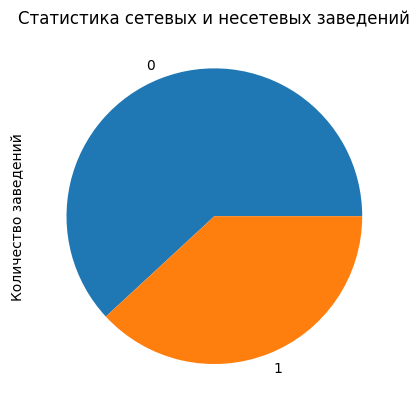

In [33]:
# Проведем анализ количества сетевых и несетевых заведений без учета дополнительных данных

full_df['chain'].value_counts()

full_df['chain'].value_counts().plot(kind='pie', 
                                     title='Статистика сетевых и несетевых заведений',
                                     legend=False,
                                     ylabel='Количество заведений',
                                     rot=0)

In [34]:
# Далее проведем анализ распределения сетевых и несетевых заведений по категориям

# Подготовим данные
df_cat_chain = full_df.groupby(['category', 'chain'])['name'].count().unstack(fill_value=0)
df_cat_chain.head()

chain,0,1
category,,
"бар,паб",596,168
булочная,99,157
быстрое питание,371,232
кафе,1597,779
кофейня,693,720


In [35]:
# Также выведем процентное соотношение сетевых/несетевых заведений по категориям

df_cat_chain['chain_share'] = round(full_df.loc[full_df['chain'] == 1].groupby('category')['name'].count() / full_df.groupby('category')['name'].count(), 2)

df_cat_chain = df_cat_chain.sort_values(by='chain_share', ascending=False)
df_cat_chain.head(8)

chain,0,1,chain_share
category,,,
булочная,99,157,0.61
пиццерия,303,330,0.52
кофейня,693,720,0.51
быстрое питание,371,232,0.38
ресторан,1313,729,0.36
кафе,1597,779,0.33
столовая,227,88,0.28
"бар,паб",596,168,0.22


<Axes: title={'center': 'Распределение сетевых и несетевых заведений по категориям'}, xlabel='Категория', ylabel='Доля сетевых заведений'>

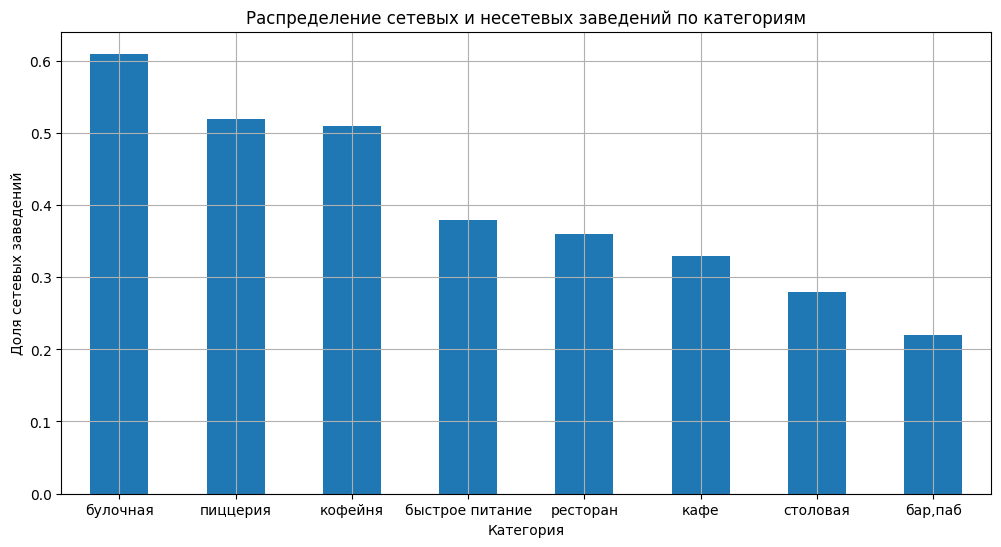

In [36]:
# Выведем визуализацию для дальнейшего анализа данных

df_cat_chain.plot(kind='bar',
                  title='Распределение сетевых и несетевых заведений по категориям',
                  legend=False,
                  y='chain_share',
                  ylabel='Доля сетевых заведений',
                  xlabel='Категория',
                  rot=0,
                  grid=True,
                  figsize=(12, 6))


Из представленной визуализации видно, что в категории 'булочная' - сетевые заведения встречаются наиболее часто (61%), на втором месте пиццерия (52%). Наименьшая доля сетевых заведений у баров (22%).


### 3.4 Анализ количества мест в заведениях

Проанализируем количество мест в заведениях, не забывая, что на этапе предобработки мы заполнили пропуски по данному полю индикативным значением '-1'. Отбросим заведения с числом мест '-1', чтобы не искажать анализ. 

In [37]:
# Создадим новый датафрейм из full_df

full_df_corr = full_df.loc[full_df['seats'] >= 0]

In [38]:
# Рассчитаем медиану для числа мест, используя скорректированный датафрейм

full_df_corr['seats'].median()

75.0

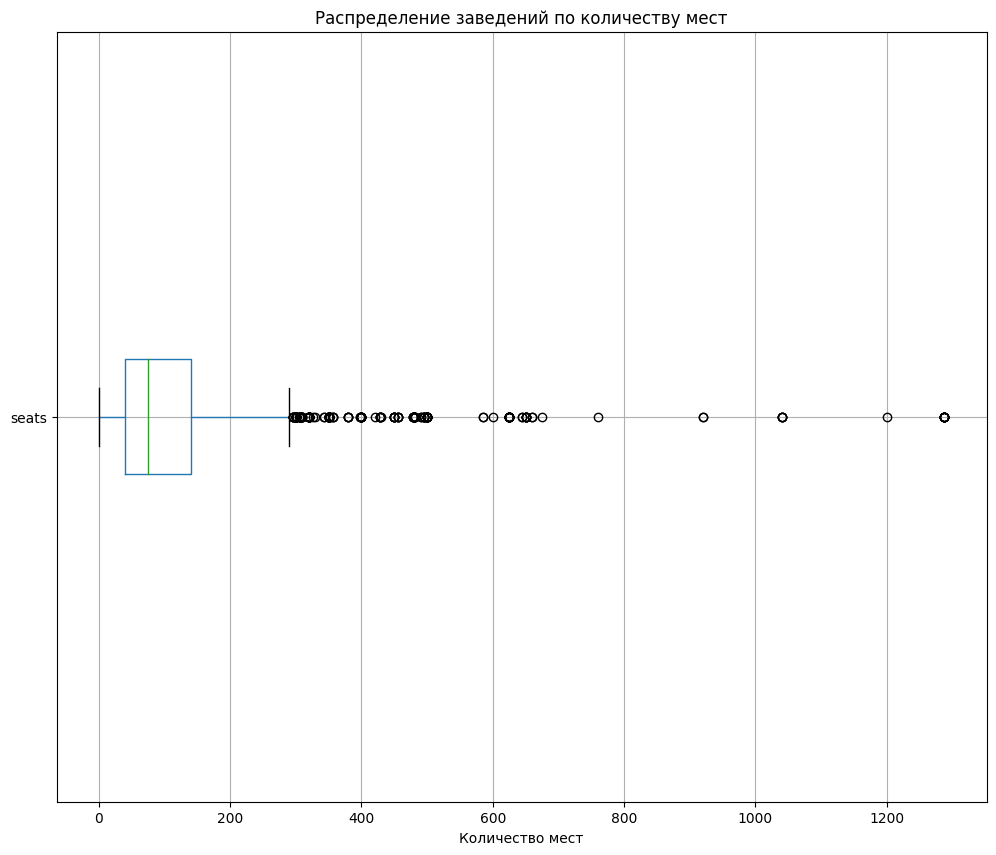

In [39]:
# Выведем визуализацию в виде графика "ящик с усами" - Диаграмму размаха для скорректированного датафрейма

boxplot = full_df_corr.boxplot(column='seats',
                          vert=False,
                          grid=True,
                          figsize=(12, 10))

# Добавляем заголовок и метку оси X
boxplot.set_title('Распределение заведений по количеству мест')
boxplot.set_xlabel('Количество мест')
plt.show()


<Axes: xlabel='seats', ylabel='Count'>

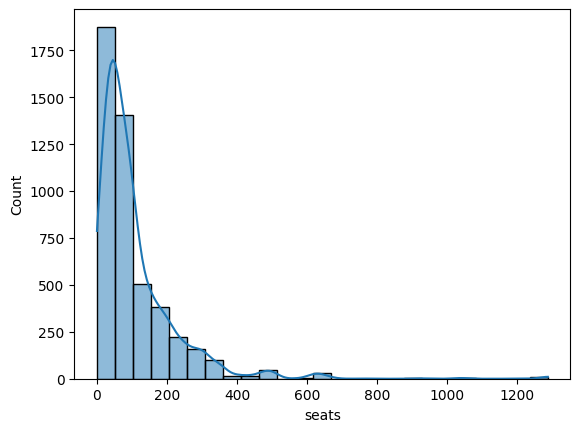

In [40]:
# Выведем визуализацию в виде гистограммы

sns.histplot(data=full_df_corr, x='seats', bins=25, kde=True)

Из визуализации и данных можно сделать вывод, что в половине заведений количество мест менее 75. Большая часть заведений располагает числом мест в диапазоне от 0 до 50.
Заведения с 0 мест - скорее всего, работают только в режиме навынос. 

Статистику также искажают выбросы - с числом мест выше 300. Возможно, это некорректные данные и число мест для заведений в датафрейме - по всей сети (для сетевых заведений).

Для подтверждения или опровержения гипотезы построим две диаграммы размаха - для сетевых и несетевых заведений.

In [41]:
# Подготовим 2 датафрейма - сетевых и несетевых (используем откорректированный датафрейм, отбросив данные, где число мест не указано)

full_df_corr_chain = full_df_corr.loc[full_df_corr['chain'] == 1]
full_df_corr_no_chain = full_df_corr.loc[full_df_corr['chain'] == 0]

# Построим две диаграммы "ящик с усами" для сравнения.

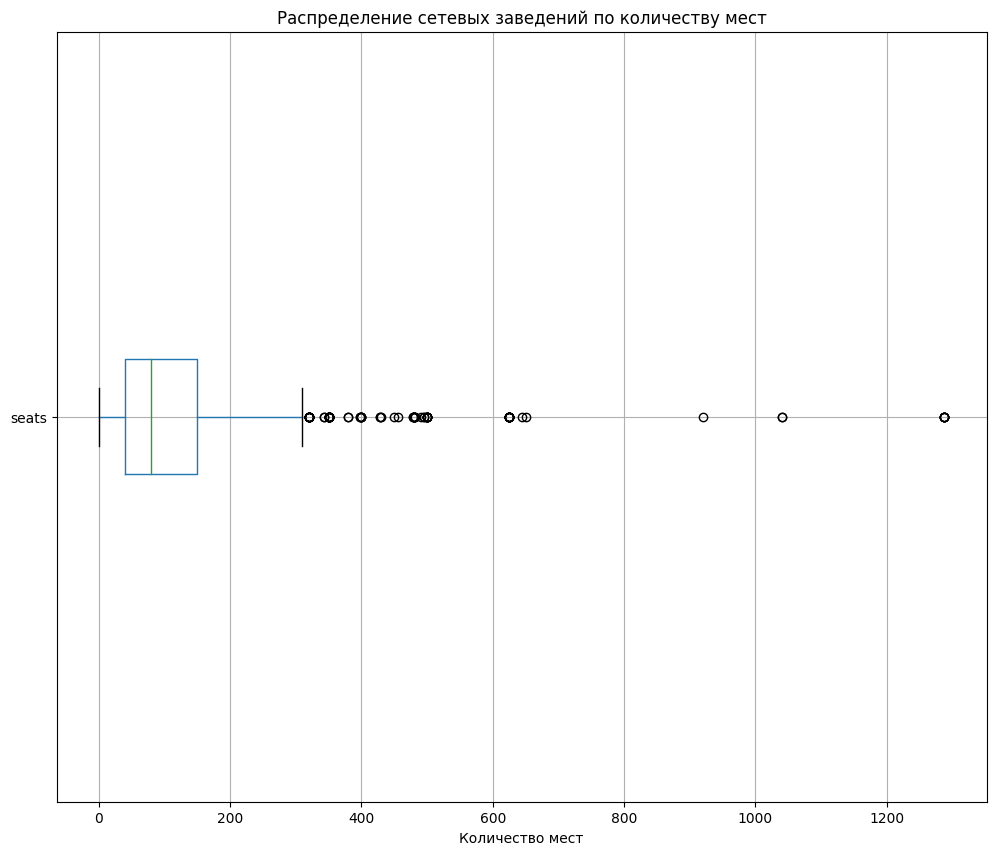

In [42]:
# Первая диаграмма для сетевых заведений
boxplot_chain = full_df_corr_chain.boxplot(column='seats',
                          vert=False,
                          grid=True,
                          figsize=(12, 10))

# Добавляем заголовок и метку оси X
boxplot_chain.set_title('Распределение сетевых заведений по количеству мест')
boxplot_chain.set_xlabel('Количество мест')
plt.show()

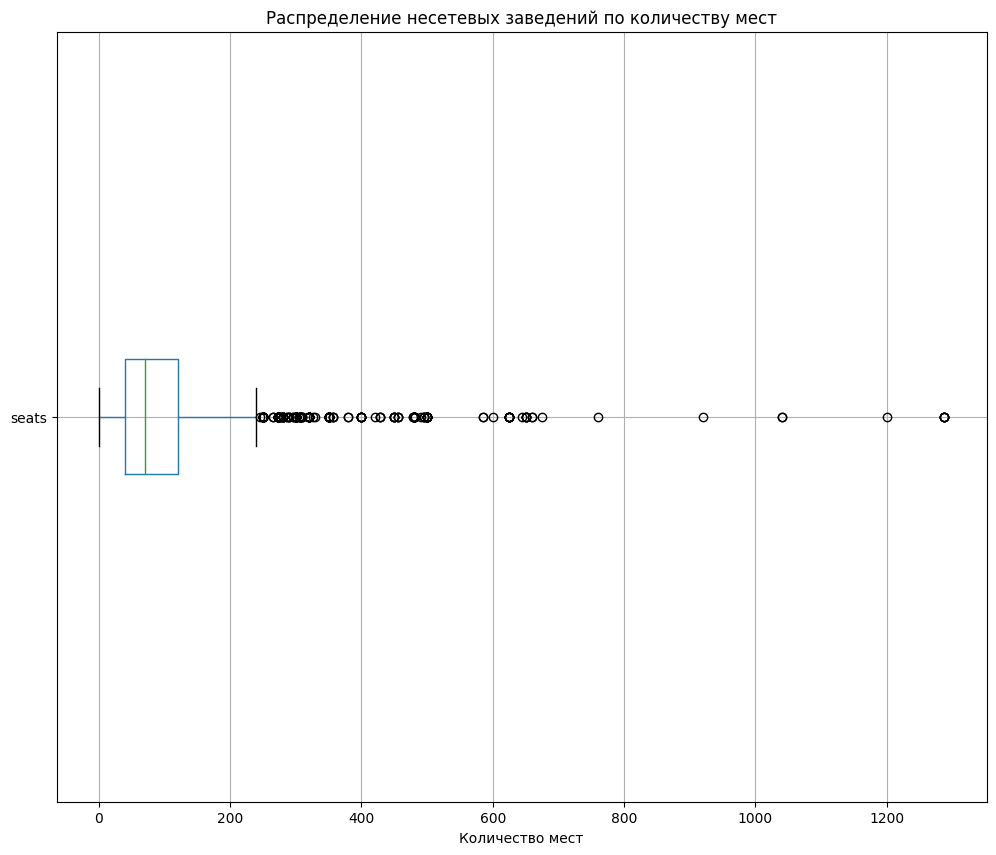

In [43]:
boxplot_no_chain = full_df_corr_no_chain.boxplot(column='seats',
                          vert=False,
                          grid=True,
                          figsize=(12, 10))

# Добавляем заголовок и метку оси X
boxplot_no_chain.set_title('Распределение несетевых заведений по количеству мест')
boxplot_no_chain.set_xlabel('Количество мест')
plt.show()

Гипотеза не подтверждена, выбросы есть как для сетевых, так и несетевых заведений. 

In [44]:
# Определим медиану числа мест в зависимости от категории заведения. 

full_df_corr_cat = full_df_corr.groupby('category', as_index=False).agg({'seats':'median'})

print(full_df_corr_cat.sort_values(by='seats',ascending=False))

          category  seats
6         ресторан   86.0
0          бар,паб   82.0
4          кофейня   80.0
7         столовая   75.5
2  быстрое питание   65.0
3             кафе   60.0
5         пиццерия   55.0
1         булочная   50.0


<Axes: title={'center': 'Медиана числа мест в зависимости от категории заведения'}, xlabel='Категория', ylabel='Число мест'>

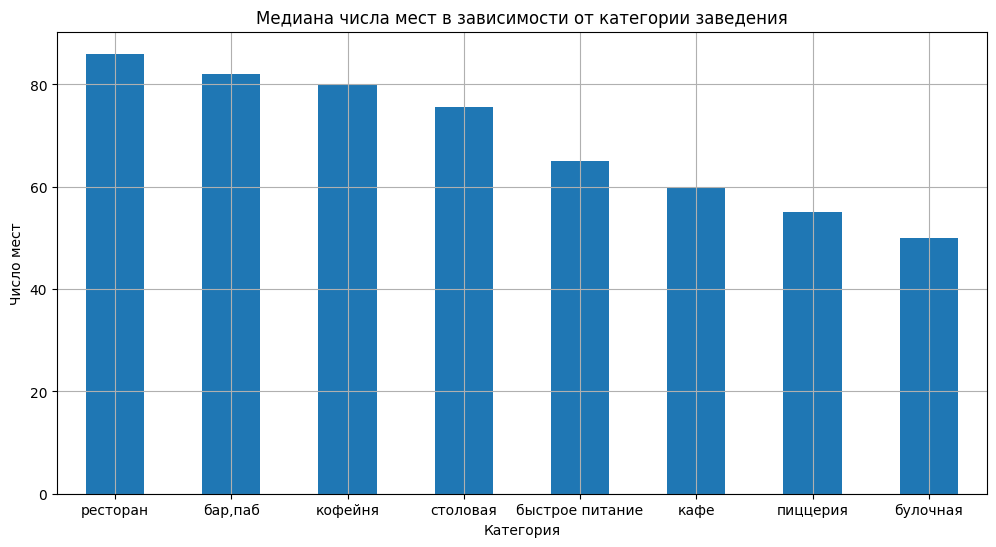

In [45]:
full_df_corr_cat.sort_values(by='seats',ascending=False).plot(kind='bar', 
                                                              title='Медиана числа мест в зависимости от категории заведения',
                                                              legend=False,
                                                              x='category',
                                                              y='seats',
                                                              ylabel='Число мест',
                                                              xlabel='Категория',
                                                              rot=0,
                                                              grid=True,
                                                              figsize=(12, 6))

### 3.5 Рейтинг заведений

In [46]:
# Предварительно посмотрим столбец Рейтинг на выбросы

full_df['rating'].describe()

count    8402.000000
mean        4.230017
std         0.470320
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

Выбросов не наблюдается, все оценки поставлены от 1 до 5.

In [47]:
# Подготовим расчет среднего рейтинга по категориям заведений

avg_rating = round(full_df.groupby('category', as_index=False)['rating'].mean().sort_values(by='rating', ascending=False), 2)

# Выведем рейтинг
print(avg_rating)

          category  rating
0          бар,паб    4.39
5         пиццерия    4.30
6         ресторан    4.29
4          кофейня    4.28
1         булочная    4.27
7         столовая    4.21
3             кафе    4.12
2  быстрое питание    4.05


<Axes: title={'center': 'Рейтинг в зависимости от категории заведения'}, xlabel='Категория', ylabel='Рейтинг'>

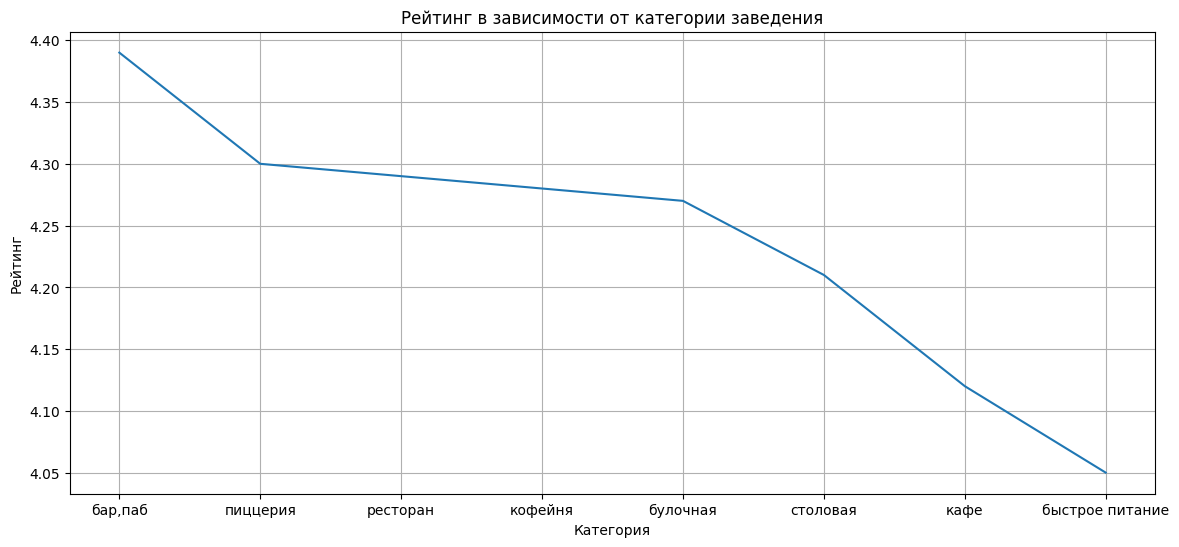

In [48]:
# Подготовим визуализацию в виде линейного графика

avg_rating.plot(kind='line', 
                title='Рейтинг в зависимости от категории заведения',
                legend=False,
                x='category',
                y='rating',
                ylabel='Рейтинг',
                xlabel='Категория',
				rot=0,
                grid=True,
				figsize=(14, 6))

Можно сделать вывод, что средний рейтинг всех заведений выше 4. Однако, рейтинг заведений быстрого питания ниже остальных, а самый высокий рейтинг имеют заведения из категории "бар, паб"

### 3.6 Корреляция рейтинга с различными парметрами

In [49]:
# Построим матрицу корреляции рейтинга с категорий заведения, округом Москвы, статусом сетевого заведения, ценовой категорией, 
# количеством мест и круглосуточным режимом работы
# Для построения матрицы использовать будем метод хи-квадрат

# Соберем датафрейм
matrix_df = full_df[['rating', 'category', 'district', 'chain', 'seats', 'price', 'is_24_7']]

# Рассчитаем матрицу, указав числовые колонки
correlation_matrix = matrix_df.phik_matrix(interval_cols=['rating', 'chain', 'seats'])

# Выведем матрицу
print(correlation_matrix)

            rating  category  district     chain     seats     price   is_24_7
rating    1.000000  0.189716  0.200761  0.107833  0.000000  0.220295  0.150365
category  0.189716  1.000000  0.174584  0.266000  0.048923  0.566933  0.244815
district  0.200761  0.174584  1.000000  0.064473  0.352440  0.202787  0.076357
chain     0.107833  0.266000  0.064473  1.000000  0.056523  0.218211  0.043488
seats     0.000000  0.048923  0.352440  0.056523  1.000000  0.088146  0.043193
price     0.220295  0.566933  0.202787  0.218211  0.088146  1.000000  0.084183
is_24_7   0.150365  0.244815  0.076357  0.043488  0.043193  0.084183  1.000000


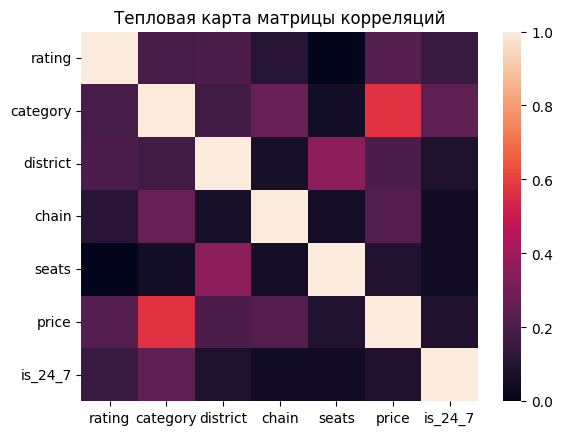

In [50]:
# Построим тепловую карту матрицы корреляций)

sns.heatmap(correlation_matrix)
plt.title('Тепловая карта матрицы корреляций')
plt.show()

Рейтинг не имеет сильной корреляции ни с одним из указанных параметров. Самая сильная - корреляции между рейтингом и ценой, однако его значение также не высоко (0,262056)

In [51]:
# Исследуем самую сильную связь. Сгруппируем данные по столбцу price и посчитаем средний рейтинг в зависимости от цен

price_rating = full_df.groupby('price')['rating'].mean()

print(price_rating.sort_values(ascending=False))

price
высокие          4.436611
выше среднего    4.386348
средние          4.297874
низкие           4.173077
Name: rating, dtype: float64


Из данной статистики видно, что с ростом ценовой категории увеличивается средний рейтинг заведений.
Визуализируем данную статистику.

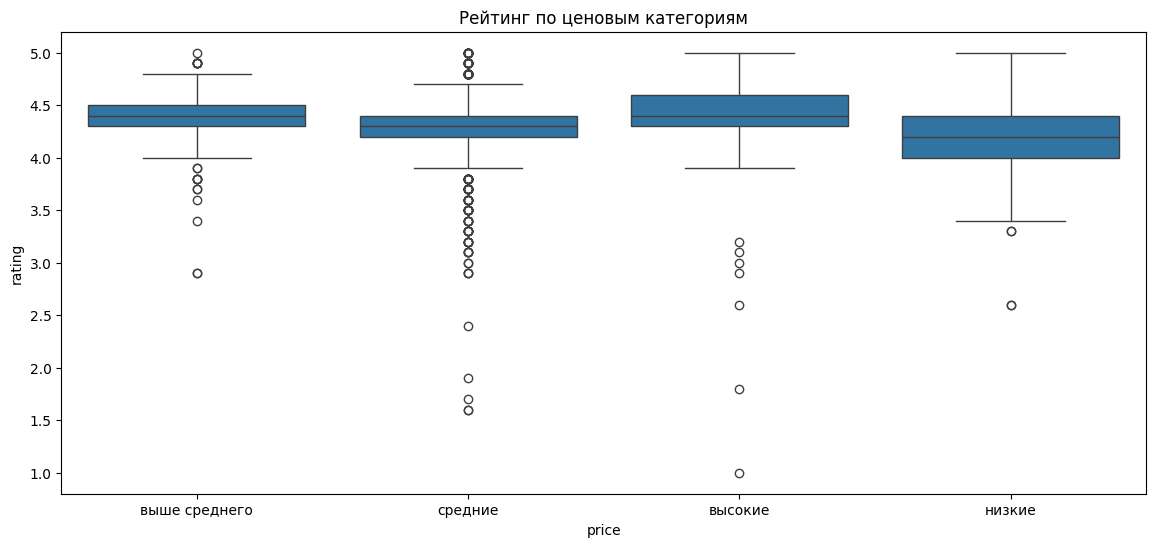

In [52]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=full_df, x='price', y='rating', width=0.8)

plt.title('Рейтинг по ценовым категориям')
plt.show()

Из визуализации видно, что для Низкой ценовой категории значения распределены шире, и ниже других категорий, также более равномерно, практически без выбросов. Для Высокой ценовой категории значения выше, однако, есть низкие выбросы

### 3.7 Топ-15 заведений

In [53]:
# Сгруппируем сетевые заведения по названию и посчитаем их средний рейтинг. Выведем на экран Топ-15 по всем сетевым заведениям

top_rating_by_name = full_df.loc[full_df['chain'] == 1].groupby(['name', 'category'], as_index=False).agg({'id': 'count',
                                                                                                           'rating': 'mean'}).sort_values(by='id', ascending=False)

top_rating_by_name['rating'] = round(top_rating_by_name['rating'], 2)
top_rating_by_name.head(15)

,name,category,id,rating
1126,шоколадница,кофейня,119,4.18
496,домино'с пицца,пиццерия,76,4.17
489,додо пицца,пиццерия,74,4.29
205,one price coffee,кофейня,71,4.06
1142,яндекс лавка,ресторан,69,3.87
72,cofix,кофейня,65,4.08
241,prime,ресторан,49,4.11
617,кофепорт,кофейня,42,4.15
632,кулинарная лавка братьев караваевых,кафе,39,4.39
963,теремок,ресторан,36,4.11


Самой популярной сетью является кофейня Шоколадница, которая лидирует с большим отрывом - 119 точек против 76 у Доминос, который на втором месте. Средний рейтинг заведений Шоколадницы - 4.17. В целом, в топ-4 категорий Кофейни и Пиццерии. На 5 место попала ЯндексЛавка, однако у нее не верно определена категория Ресторан. 

<Axes: title={'center': 'Количество точек у Топ-15 сетевых заведений по категориям'}, xlabel='Категория', ylabel='Число заведений'>

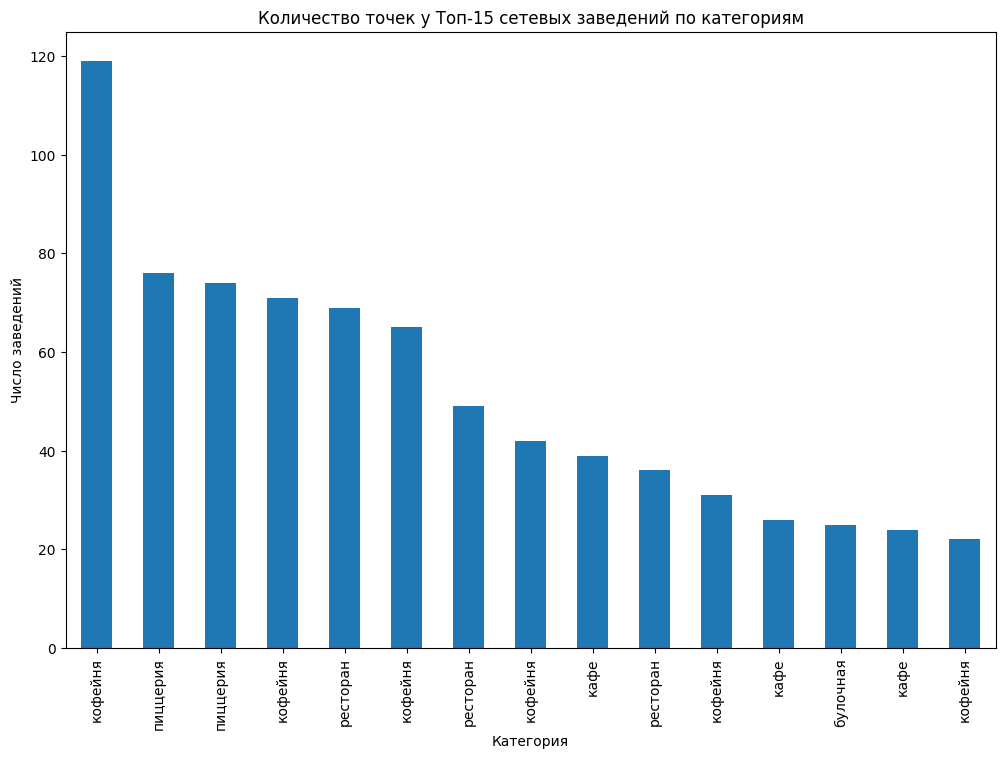

In [54]:
# Построим график совместного распределения для Топ-15

top_rating_by_name.head(15).sort_values(by='id', ascending=False).plot(kind='bar', 
                                                                       x='category', 
                                                                       y='id',
                                                                       xlabel='Категория',
                                                                       ylabel='Число заведений',
                                                                       legend=False,
                                                                       title='Количество точек у Топ-15 сетевых заведений по категориям',
                                                                       figsize=(12,8))

На графике видны распределения количества точек у сетевых заведений и их категория. Самая популярная категория Кофейня, за ней идут пиццерии и снова кофейня. Явно отличается отрыв первого места по числу точек от других сетей.

<Axes: title={'center': 'Количество точек у Топ-15 сетевых заведений по категориям'}, xlabel='Рейтинг', ylabel='Число заведений'>

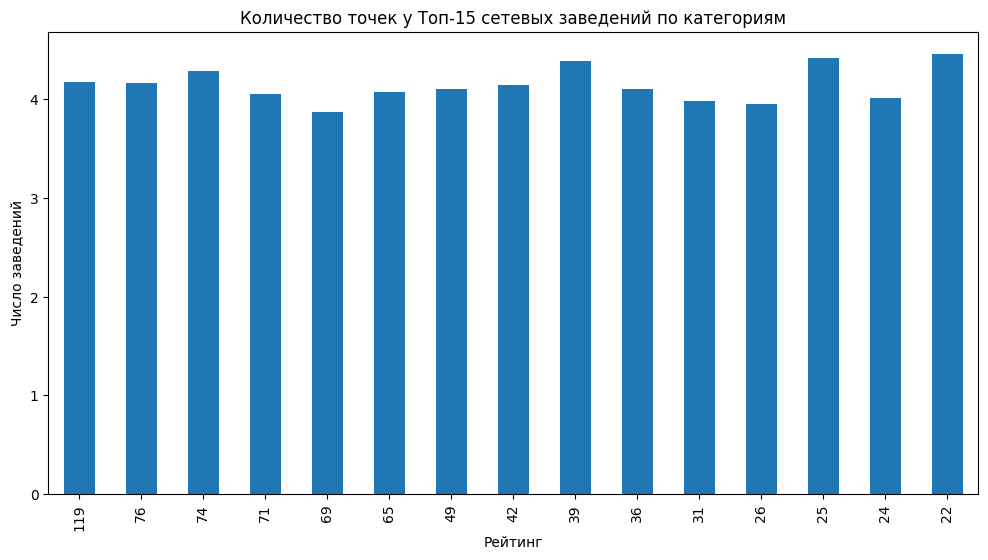

In [55]:
# Еще одна визуализация покажет связь количества точек и рейтинга

top_rating_by_name.head(15).sort_values(by='id', ascending=False).plot(kind='bar', 
                                                                           x='id', 
                                                                           y='rating',
                                                                           xlabel='Рейтинг',
                                                                           ylabel='Число заведений',
                                                                           legend=False,
                                                                           title='Количество точек у Топ-15 сетевых заведений по категориям',
                                                                           figsize=(12,6))

Из графика можно сделать вывод, что рейтинг не кореллирует с числом точек. В целом, видно, что заведения с большим числом точек имеют рейтинг ниже среднего, расчитанного выше в данном исследовании. 

### 3.8 Средний чек и местоположение заведений

In [56]:
# Подготовим группировку данных по округам Москвы и расчитаем медианное значение среднего чека по округам.

med_bill_district = round(full_df.groupby('district')['middle_avg_bill'].median(), 1).sort_values(ascending=False)

print('Медианное значение среднего чека:\n\n', med_bill_district, '\n')


mean_bill_district = round(full_df.groupby('district')['middle_avg_bill'].mean(), 1).sort_values(ascending=False)

print('Среднее значение среднего чека:\n\n', mean_bill_district, '\n')

Медианное значение среднего чека:

 district
западный административный округ            1000.0
центральный административный округ         1000.0
северо-западный административный округ      700.0
северный административный округ             650.0
юго-западный административный округ         600.0
восточный административный округ            575.0
северо-восточный административный округ     500.0
южный административный округ                500.0
юго-восточный административный округ        450.0
Name: middle_avg_bill, dtype: float64 

Среднее значение среднего чека:

 district
центральный административный округ         1191.1
западный административный округ            1053.2
северный административный округ             928.0
южный административный округ                834.4
северо-западный административный округ      822.2
восточный административный округ            820.6
юго-западный административный округ         792.6
северо-восточный административный округ     716.6
юго-восточный админист

Из таблицы выше видно, что средний чек в Центральном округе выше, чем чек в остальных округах (1191 р). 
Однако медианное значение чеков равно для Центрального и Западного округов (1000 р), что может объясняться наличием выбросов, которые повышают среднее значение чека.

Разница между самым высоким медианным чеком и самым низким по округам - более, чем в 2 раза (1000 р против 450 р). 
Подготовим визуализацию данных, которая покажет уменьшение среднего чека в зависимости от округа

<Axes: title={'center': 'Медианный чек по округам Москвы'}, xlabel='Округ', ylabel='Медианный чек'>

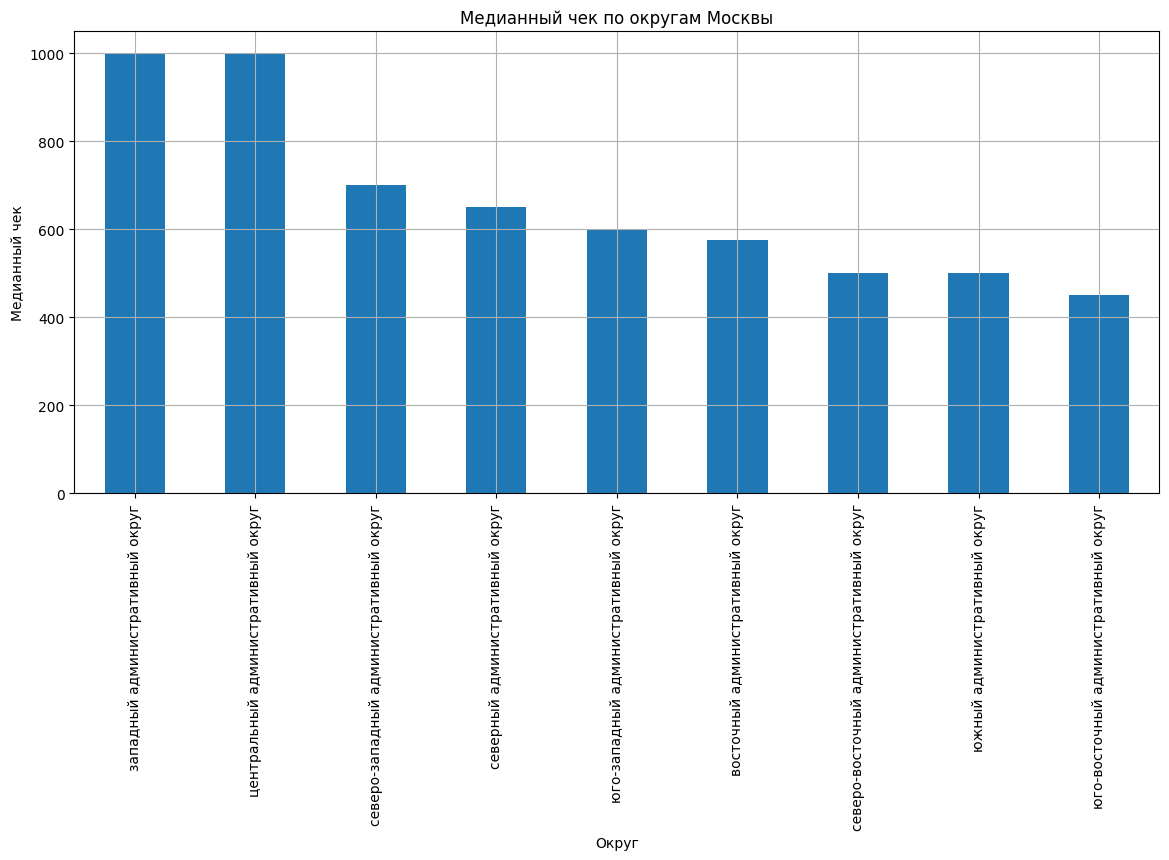

In [57]:
med_bill_district.plot(kind='bar', 
                       title='Медианный чек по округам Москвы',
                       legend=False,
                       x='district',
                       y='middle_avg_bill',
                       ylabel='Медианный чек',
                       xlabel='Округ',
                       rot=90,
                       grid=True,
                       figsize=(14, 6))

## 4. Итоговый вывод и рекомендации

В ходе исследований были проанализированы более 8 тысяч заведений в Москве, расположенные в 9 округах. В исследование не вошли округа Москвы, расположенные за МКАД.
Для исследования были предоставлены данные по категории заведений, количеству мест, рейтингу, среднему чеку, времени работы, принадлежность заведений к той или иной сети.

#### Общие выводы

В Москве представлено больше несетевых заведений, чем сетевых. Медиана количества мест в заведениях: 75. Рестораны имеют большее количество посадочных мест, чем иные категории.

Рейтинг заведений напрямую не зависит от числа мест, среднего чека, расположения заведения. Можно предположить, что рейтинг зависит от "человеческого фактора" - уровня обслуживания. В сетевых заведениях с большим числом точек - рейтинг ниже.
Также можно заметить, что рейтинг в барах (4.4) существенно выше, чем рейтинг в заведениях быстрого питания (4.05).

По ценовым признакам - средний чек в самом дорогом округе практически в два раза выше (1191 р.), чем в самом дешевом (654 р.). Однако, для полной картины не хватает понимания затрат на открытие или арендную плату для того или иного типа заведения в различных округах. В целом, стоимость среднего чека может напрямую коррелировать с уровнем стоимости аренды помещений в округах.



#### Вывод для инвесторов

Исходя из данного исследования, можно дать рекомендацию по открытию заведения в Западном или Центральном округе, так как там самый высокий средний (1191р и 1053р) и медианный чек (1000р). Однако, при этом Центральный округ является более конкурентным - там большее число заведений (2242) против 851 в Западном округе. 

Если будет принято решение открывать сетевое заведение, то самые популярные сетевые заведения это булочные (61%) и пиццерии (52%), что может объясняться более широким выбором франшиз и стандартных путей для открытия.